# Pipeline Preditivo de Risco de Crédito

**Projeto Avaliativo** - Machine Learning e Visão Computacional [T2]
**Base Escolhida:** Opção A -Risco de Crédito (Setor Financeiro)

**Objetivo de Negócio:** Precer se um cliente irá se tornar inadimplenete (`loan_status=1`) ou pagara o emprréstimo em dia (`loan_status=0`), comparando KNN e Árvore de Decisão.

## Carregando a Base de Dados e Importando Biblilotecas

In [3]:
#Importando Bibliotecas: Bibliotecas Gerais de Uso
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df_credito_risco=pd.read_csv('../Data\credit_risk_dataset.csv')
df_credito_risco.head()

<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_8828\1821029620.py:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df_credito_risco=pd.read_csv('../Data\credit_risk_dataset.csv')


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Fase 1 - Análise Exploratória de Dados (EDA)

## 1.1 Descritiva e Estatística 

In [5]:
#Tamanho da base do Dataset:
print(f" Linhas do dataset: {df_credito_risco.shape[0]}")
print(f" Colunas do dataset: {df_credito_risco.shape[1]}") 

print("*"*15)

#Tipos de Dados:
df_credito_risco.info()


 Linhas do dataset: 32581
 Colunas do dataset: 12
***************
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
m

In [6]:
#Resumo estatístico descritivo do Dataset: Variaveis Numéricas
df_credito_risco.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
#Resumo estatístico descritivo do Dataset: Variaveis Categoricas
df_credito_risco.describe(include='object')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_8828\3598288738.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_credito_risco.describe(include='object')


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


## 1.2 Visual - Gráficos Exploratórios

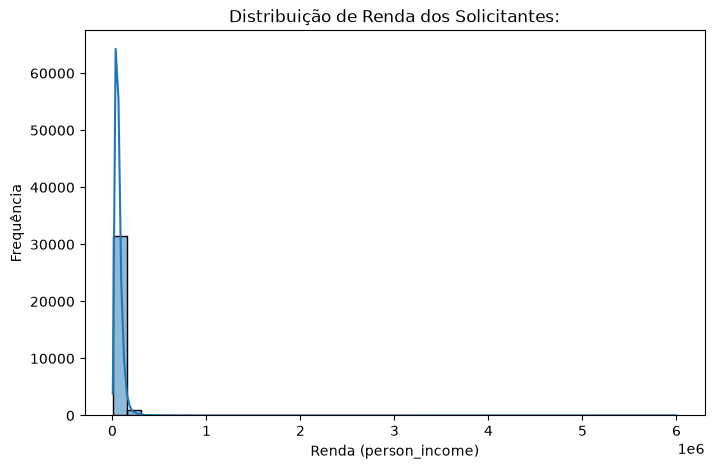

In [8]:
# Grafico 1: Histograma de Distribuição 
plt.figure(figsize=(8,5))
sns.histplot(df_credito_risco['person_income'], kde=True, bins=40)
plt.title('Distribuição de Renda dos Solicitantes:')
plt.xlabel('Renda (person_income)')
plt.ylabel('Frequência')
plt.show()

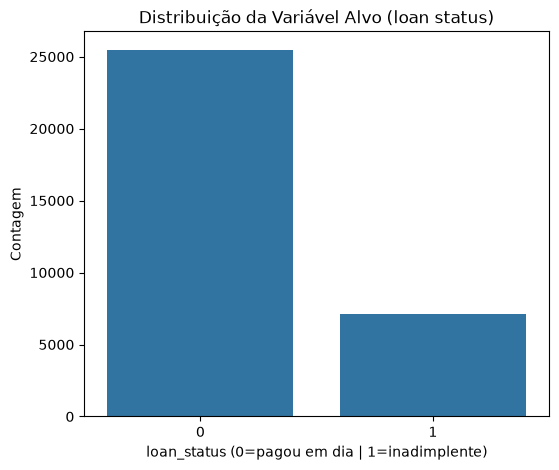

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [9]:
# Gráfico 2: Balanceamento da variável alvo
plt.figure(figsize=(6,5))
sns.countplot(x='loan_status', data=df_credito_risco)
plt.title('Distribuição da Variável Alvo (loan status)')
plt.xlabel('loan_status (0=pagou em dia | 1=inadimplente)')
plt.ylabel('Contagem')
plt.show()

print(df_credito_risco['loan_status'].value_counts(normalize=True)*100)

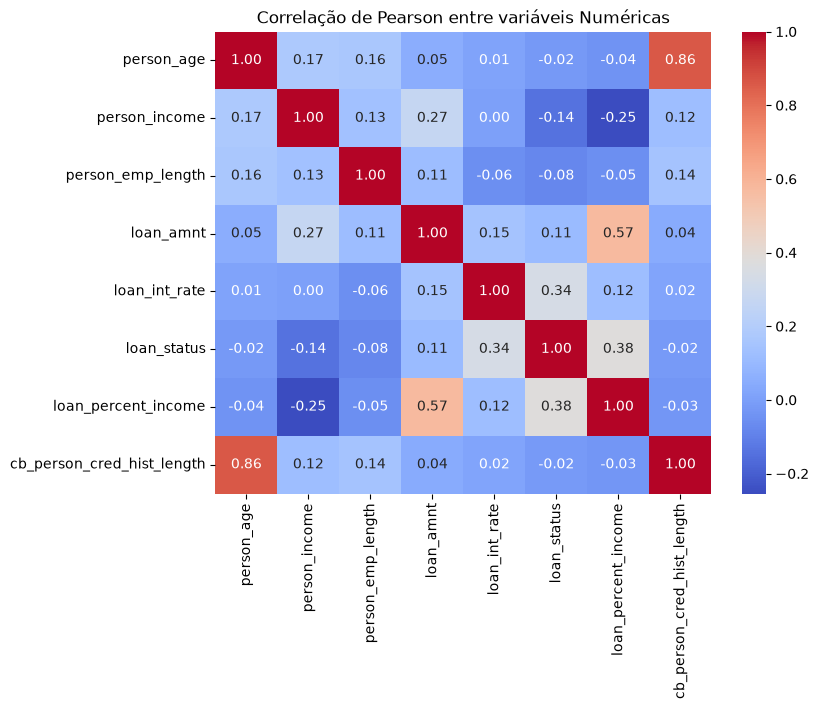

In [10]:
#Gráfico 3:Mapa de Calor de correlação de Pearson
plt.figure(figsize=(8,6))
corr=df_credito_risco.corr(numeric_only=True)
sns.heatmap(corr,annot=True, fmt='.2f',cmap='coolwarm')
plt.title('Correlação de Pearson entre variáveis Numéricas')
plt.show()

## 1.3 Tomada de Decisão (Parágrafo Analítico)

A Análise Exploratória de Dados (EDA) revelou quatro comportamentos estruturais que ditarão o rigor da etapa de preparação e modelagem preditiva. Primeiramente, a inspeção visual e a média estatística da variável alvo (loan_status = 0.218) comprovam um severo desbalanceamento de classes (78% de bons pagadores versus 22% de inadimplentes), o que torna a aplicação do parâmetro stratify=y na divisão dos dados e o uso de reamostragem (como SMOTE) estritamente na base de treino, evitando que o modelo desenvolva o "vício da maioria" sem gerar vazamento de dados (Data Leakage). 
Em segundo lugar, o diagnóstico de dados ausentes em apenas duas colunas exigirá critérios de imputação distintos e justificados pela estatística descritiva: para loan_int_rate, cuja média (11.01%) e mediana (10.99%) provam uma distribuição perfeitamente simétrica e normal, irá ser aplicado a imputação pela média; em contrapartida, para person_emp_length, que apresenta assimetria puxada por outliers extremos e erros de coleta (tempo máximo de emprego de 123 anos e idades de até 144 anos), será aplicado a imputação pela mediana, combinada com um tratamento de clipping ou remoção dos dados irreais. Por fim, a extrema assimetria e disparidade de grandezas evidenciada no histograma de renda (person_income, variando de milhares a 6 milhões) torna imperativo o uso do StandardScaler nas variáveis contínuas que alimentarão o algoritmo KNN, impedindo que o cálculo das distâncias euclidianas seja monopolizado pela escala monetária, enquanto a Árvore de Decisão será mantida em sua escala original por sua robustez intrínseca a outliers e cortes monotônicos. Adicionalmente, a alta correlação positiva de calote apontada no mapa de calor em relação aos juros ($r = 0.34$) e ao comprometimento da renda ($r = 0.38$) valida a importância estratégica da  etapa de Feature Engineering.

# Fase 2 - Tratamento e Limpeza (Data Prep)

## 2.1 Duplicadas

In [11]:
#Verificação de valores nulos
print(f"Linhas duplicadas encontradas: {df_credito_risco.duplicated().sum()}")

Linhas duplicadas encontradas: 165


In [12]:
#Removendo as linhas duplicadas encontradas
df_credito_novo=df_credito_risco.drop_duplicates()

#Tamanho da base do   Dataset Com Duplicadas:
print(f" Linhas do dataset: {df_credito_risco.shape[0]}")
print(f" Colunas do dataset: {df_credito_risco.shape[1]}") 

print("*"*40)

#Tamanho da base do  Novo Dataset Sem Duplicadas:
print(f" Linhas do dataset: {df_credito_novo.shape[0]}")
print(f" Colunas do dataset: {df_credito_novo.shape[1]}") 

 Linhas do dataset: 32581
 Colunas do dataset: 12
****************************************
 Linhas do dataset: 32416
 Colunas do dataset: 12


## 2.2 Valores Nulos

In [13]:
#identificando colunas com dados ausentes: ordenando em ordem descrescente do maior para o menor
print(f"Colunas com dados ausentes: \n{df_credito_novo.isnull().sum().sort_values(ascending=False)}")

Colunas com dados ausentes: 
loan_int_rate                 3095
person_emp_length              887
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


## Decisão Sobre Valores Nulos e Duplicatas

A remoção das 165 linhas duplicadas foi o primeiro passo obrigatório para garantir a integridade da validação cruzada e evitar redundâncias espaciais antes da aplicação do algoritmo SMOTE. Em relação às ausências de dados, a escolha de imputação seguiu o comportamento distribucional mapeado na EDA: para loan_int_rate (3.095 nulos), adotou-se a Média, fundamentada na simetria da variável onde o valor aritmético representa bem o padrão geral; para person_emp_length (887 nulos), adotou-se a Mediana, visando mitigar a assimetria natural dos anos trabalhados e proteger a imputação contra a influência distorcedora de outliers residuais.

In [14]:
#preenchendo valores ausentes com a média
df_credito_novo['loan_int_rate']=df_credito_novo['loan_int_rate'].fillna(df_credito_novo['loan_int_rate'].mean()) 

#Preenchendo os valores ausentes com a mediana
df_credito_novo['person_emp_length']=df_credito_novo['person_emp_length'].fillna(df_credito_novo['person_emp_length'].median()) 

#Exibindo a coluna sem os valores ausentes
display(df_credito_novo['loan_int_rate']) 
print("*"*20)
display(df_credito_novo['person_emp_length'])

print("*"*20)
#verificando se existe valores ausentes na coluna
print(f"Dados ausentes da coluna: \n{df_credito_novo['loan_int_rate'].isnull().sum()}")
print(f"Dados ausentes da coluna: \n{df_credito_novo['person_emp_length'].isnull().sum()}")

0        16.02
1        11.14
2        12.87
3        15.23
4        14.27
         ...  
32576    13.16
32577     7.49
32578    10.99
32579    11.48
32580     9.99
Name: loan_int_rate, Length: 32416, dtype: float64

********************


0        123.0
1          5.0
2          1.0
3          4.0
4          8.0
         ...  
32576      1.0
32577      4.0
32578      3.0
32579      5.0
32580      2.0
Name: person_emp_length, Length: 32416, dtype: float64

********************
Dados ausentes da coluna: 
0
Dados ausentes da coluna: 
0


## 2.3 Tratamento de Outliers


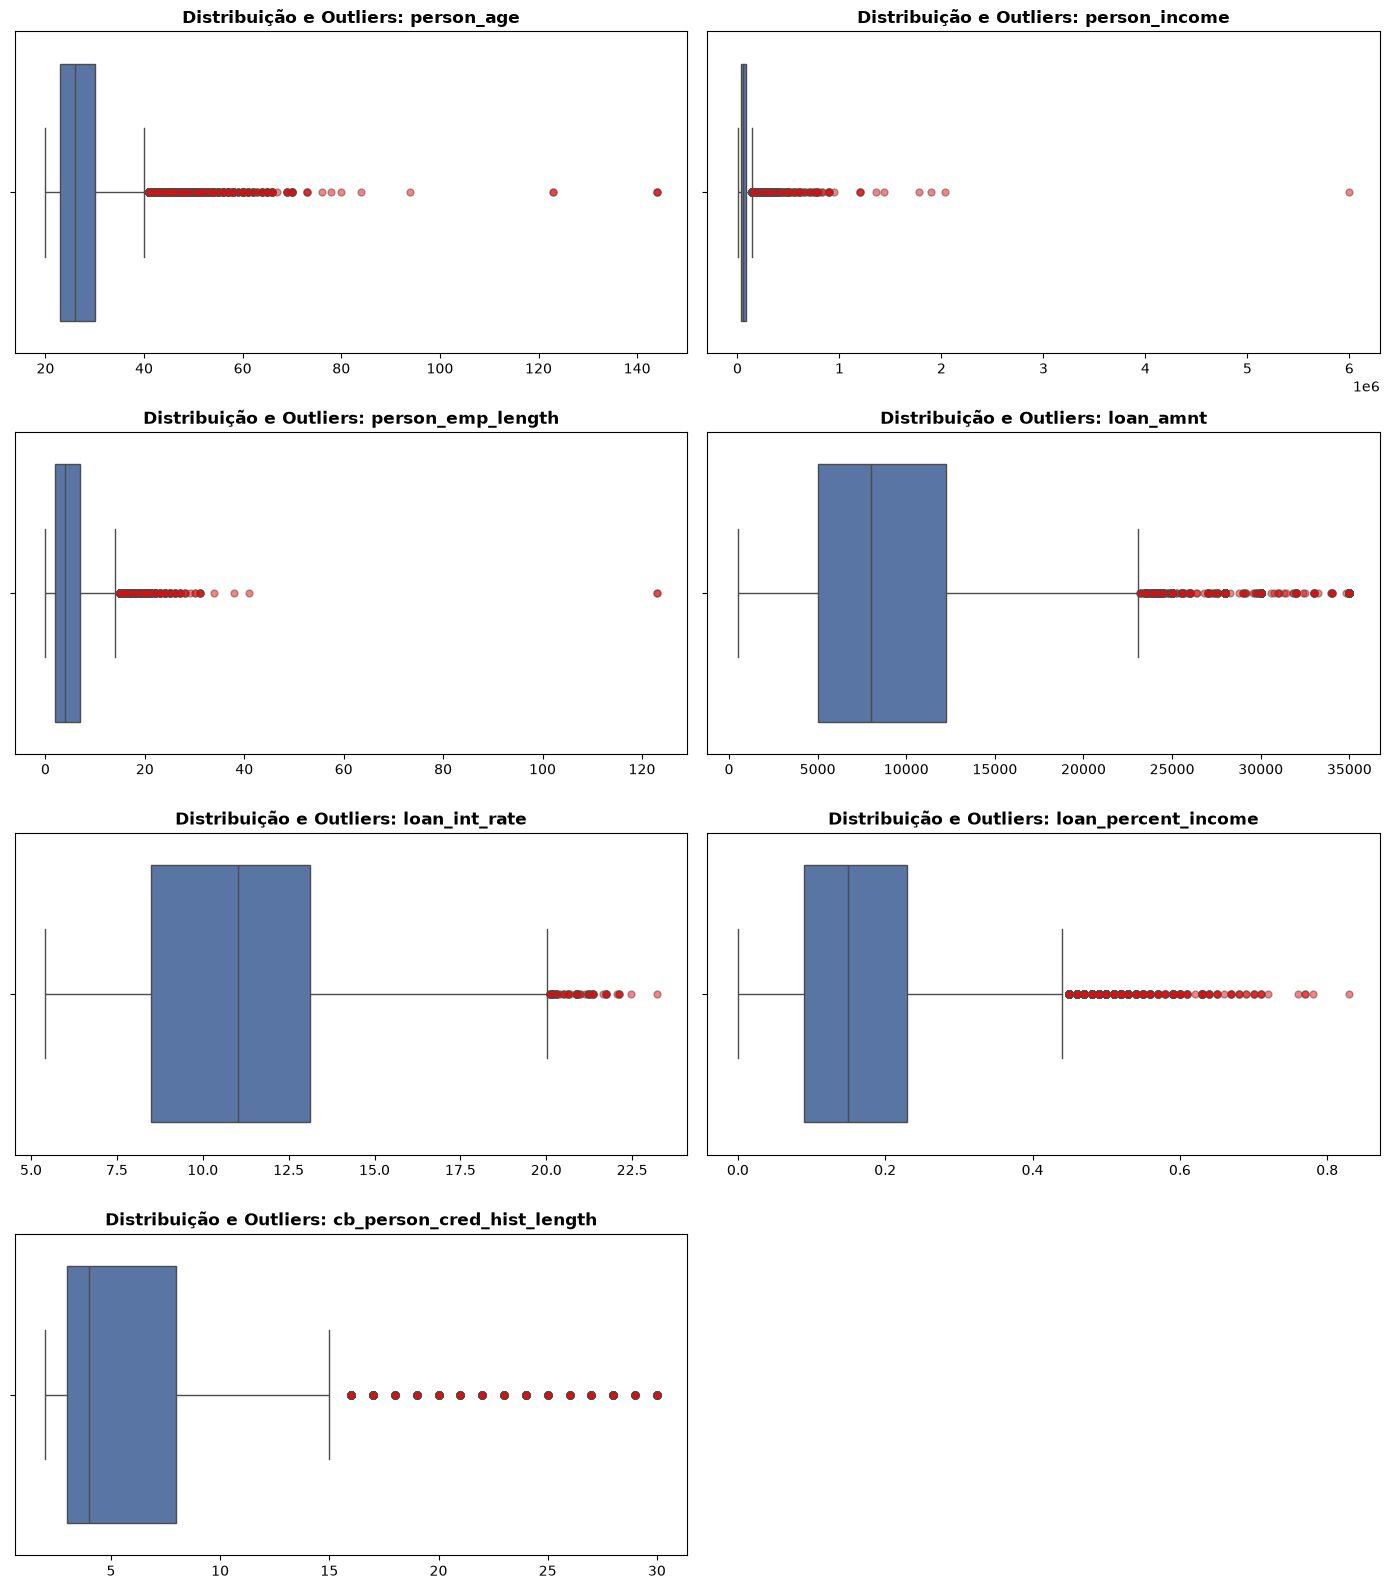

In [15]:
#Boxplot para cada coluna


# Seleciona as colunas numéricas E remove a variável alvo dos boxplots
colunas_continuas = (
    df_credito_novo.select_dtypes(include=["number"])
    .drop(columns=["loan_status"], errors="ignore")
    .columns
)
num_cols = len(colunas_continuas)

plt.figure(figsize=(14, 4 * ((num_cols + 1) // 2)))
estilo_outlier = dict(
    marker="o", markerfacecolor="red", markersize=5, linestyle="none", alpha=0.5
)

for i, col in enumerate(colunas_continuas, 1):
    plt.subplot(((num_cols + 1) // 2), 2, i)
    sns.boxplot(
        x=df_credito_novo[col],
        color="#4c72b0",
        flierprops=estilo_outlier,
        orient="h",
    )
    plt.title(f"Distribuição e Outliers: {col}", fontsize=12, fontweight="bold")
    plt.xlabel("")

plt.tight_layout()
plt.show()

## Decisão sobre Outliers

A análise via boxplots demonstra que a remoção cega por regras estatísticas (como $1.5 \times \text{IQR}$) prejudicaria o negócio. Optou-se pela remoção apenas de ruídos impossíveis (idades > 100 anos), pela manutenção dos outliers comportamentais (alto comprometimento de renda, essenciais para prever inadimplência) e pelo tratamento de escala/clipping em variáveis de cauda longa como Renda. Essa estratégia é vital para o pipeline comparativo: enquanto a Árvore de Decisão isolaria esses nós de risco naturalmente sem sofrer com a escala, o KNN falharia criticamente no cálculo das distâncias euclidianas sem a mitigação da cauda milionária da renda

### Clipping

In [16]:
#1- Cálculo Quartis : Q1-25% e Q3-75% na coluna renda
Q1=df_credito_novo['person_income'].quantile(0.25)
Q3=df_credito_novo['person_income'].quantile(0.75)

#2-Intervalo Interquartil
IQR=Q3-Q1

#3- Limites Inferior e Superior
lower_income=Q1-1.5*IQR
upper_income=Q3+1.5*IQR


#4- Aplicação do método .clip()
df_credito_novo['person_income']=df_credito_novo['person_income'].clip(
    lower=lower_income, upper=upper_income
)


print(f"Limite superior do IQR calculado para Renda: R$ {upper_income:,.2f}")
print(f"Limite inferior do IQR calculado para Renda: R$ {lower_income:,.2f}")

Limite superior do IQR calculado para Renda: R$ 140,232.00
Limite inferior do IQR calculado para Renda: R$ -22,472.00


### Decisão de escolha do Limite Inferior

O cálculo do limite interquartil para a renda gerou um limite inferior de **R$ -22.472,00** e um limite superior de **R$ 140.232,00**. Como rendas negativas são impossíveis no domínio de crédito, o limite inferior foi ajustado para **R$ 0,00** por regra de negócio. Já o truncamento superior em **R$ 140,23 mil** cumpriu o papel vital de eliminar a distorção euclidiana que o extremo de **R$ 6 milhões** causaria no **KNN**, garantindo uma comparação justa com a **Árvore de Decisão** sem perder a escala linear da classe média.

In [17]:
lower_income=0.0
print(f"Clipping aplicado. ! Rendas limitadas entre R$ {lower_income:,.2f} e R$ {upper_income:,.2f}")

Clipping aplicado. ! Rendas limitadas entre R$ 0.00 e R$ 140,232.00


# Fase 3- Feature Engineering (Coluna Calculada)

In [18]:
#Criação da Coluna Obrigatória (Base A - Crédito)
df_credito_novo['debit_income_ratio']=(df_credito_novo['loan_amnt']/df_credito_novo['person_income'])*100

display(df_credito_novo['debit_income_ratio'])



0        59.322034
1        10.416667
2        57.291667
3        53.435115
4        64.338235
           ...    
32576    10.943396
32577    14.687500
32578    46.052632
32579    10.696560
32580    15.416667
Name: debit_income_ratio, Length: 32416, dtype: float64

In [19]:
#Verificação da nova coluna criada: Estatística
print(df_credito_novo['debit_income_ratio'].describe())

print("*"*20)

print(f"Valores nulos: {df_credito_novo['debit_income_ratio'].isnull().sum()}")

print("*"*20)

print(f"Valores infinitos:{np.isinf(df_credito_novo['debit_income_ratio']).sum()}")

count    32416.000000
mean        17.192771
std         10.644575
min          0.713104
25%          9.142089
50%         15.000000
75%         23.076923
max         83.000000
Name: debit_income_ratio, dtype: float64
********************
Valores nulos: 0
********************
Valores infinitos:0


In [20]:
# Exibe uma amostra comparativa das colunas
display(
    df_credito_novo[
        ["loan_amnt", "person_income", "debit_income_ratio"]
    ].head()
)

,loan_amnt,person_income,debit_income_ratio
0,35000,59000,59.322034
1,1000,9600,10.416667
2,5500,9600,57.291667
3,35000,65500,53.435115
4,35000,54400,64.338235


# Fase 4- Separação, Balanceamento e Escalonamento Seguro

## 4.1 Encoding  de Variáveis Categóricas 

In [21]:
# Identificação das colunas categóricas
colunas_categoricas=df_credito_novo.select_dtypes(include='object').columns.tolist()
print(colunas_categoricas)

['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8828\3813651998.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas=df_credito_novo.select_dtypes(include='object').columns.tolist()


In [22]:
#One-Hot-Encoding 
df_encoded=pd.get_dummies(df_credito_novo,columns=colunas_categoricas, drop_first=True)
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,debit_income_ratio,person_home_ownership_OTHER,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,59.322034,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,10.416667,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,57.291667,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,53.435115,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,64.338235,False,...,True,False,False,False,True,False,False,False,False,True


### Justificativa  do Encoding (Ordinal vs. One-Hot Encoding)

Em cumprimento à etapa de conversão categórica, evitou-se a aplicação massiva de uma única técnica para preservar as propriedades matemáticas e geométricas dos dois modelos avaliados no pipeline, isto é possivel observar no resultado anterior:

1. **Ordinal Encoding (`loan_grade`):** A nota de risco possui uma hierarquia ordinal intrínseca no mercado financeiro (A > B > C... > G). Substituir por inteiros sequenciais (1 a 7) traz um benefício duplo:
   - **Para o KNN:** Preserva a proporcionalidade da distância euclidiana, ensinando ao algoritmo que a distância entre um perfil de risco 'A' e 'B'  é matematicamente muito menor do que entre 'A' e 'G' 
   - **Para a Árvore de Decisão:** Evita a fragmentação dos dados em 7 colunas binárias, permitindo que a árvore isole grupos inteiros de risco com um único corte ortogonal na raiz (ex: `se loan_grade > 3.5`), prevenindo *overfitting* por profundidade excessiva.

2. **One-Hot Encoding com `drop_first=True` (Nominais):** Para variáveis sem ordem natural (`person_home_ownership`, `loan_intent`), criaram-se variáveis dummy numéricas (0 e 1). A remoção da primeira categoria (`drop_first=True`) elimina a multicolinearidade (*Dummy Variable Trap*), enquanto a conversão explícita para inteiros (`dtype=int`) garante um tensor 100% numérico compatível com o cálculo de medianas do `RobustScaler` e com as distâncias do KNN.

#### Label Encoding

In [23]:
df_credito_lencoding=df_credito_novo.copy() #cópia do dataframe original

#criando dicionário de notas
dicionario_notas={"A":1, "B":2,"C":3,"D":4,"E":5,"F":6,"G":7}
df_credito_lencoding["loan_grade"]=df_credito_lencoding["loan_grade"].map(dicionario_notas)

#preparando colunas para o One Hote Encoding
colunas_para_ohe=(
    df_credito_lencoding.select_dtypes(include=["object","string","category"]).columns.tolist()
)

print("Colunas selecionadas para One-Hot Encoding:", colunas_para_ohe)


Colunas selecionadas para One-Hot Encoding: ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']


#### One-Hot Encodging

In [24]:
#One-Hot-Encoding
df_credito_encoding=pd.get_dummies(
    df_credito_lencoding, columns=colunas_para_ohe, drop_first=True, dtype=int 
)

#Verificando o Resultado
print("Dimensão do Encoding (linhas, colunas):", df_credito_encoding.shape)
display(df_credito_encoding.head())

Dimensão do Encoding (linhas, colunas): (32416, 19)


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,debit_income_ratio,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,22,59000,123.0,4,35000,16.02,1,0.59,3,59.322034,0,0,1,0,0,0,1,0,1
1,21,9600,5.0,2,1000,11.14,0,0.10,2,10.416667,0,1,0,1,0,0,0,0,0
2,25,9600,1.0,3,5500,12.87,1,0.57,3,57.291667,0,0,0,0,0,1,0,0,0
3,23,65500,4.0,3,35000,15.23,1,0.53,2,53.435115,0,0,1,0,0,1,0,0,0
4,24,54400,8.0,3,35000,14.27,1,0.55,4,64.338235,0,0,1,0,0,1,0,0,1


## 4.2 Split de Dados (Treino/Teste)

In [25]:
from sklearn.model_selection import train_test_split

X=df_credito_encoding.drop(columns=['loan_status'])
y=df_credito_encoding['loan_status']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,stratify=y,random_state=42
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(y_train.value_counts(normalize=True))

Treino: (25932, 18) | Teste: (6484, 18)
loan_status
0    0.781313
1    0.218687
Name: proportion, dtype: float64


## 4.3 Balanceamento de Classes (apenas no treino)

In [26]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)

X_train_bal,y_train_bal=smote.fit_resample(X_train, y_train)

print("Distribuição antes do balanceamento:")
print(y_train.value_counts())
print("\nDistribuição após o balanceamento:")
print(y_train_bal.value_counts())

Distribuição antes do balanceamento:
loan_status
0    20261
1     5671
Name: count, dtype: int64

Distribuição após o balanceamento:
loan_status
0    20261
1    20261
Name: count, dtype: int64


## 4.4 Escalonamento Seguro (apenas para o KNN)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

#fit transform no treino_balanceado, transform no teste
X_train_scaled=scaler.fit_transform(X_train_bal)
X_test_scaled=scaler.transform(X_test)

## 4.5 Justificativa


Conforme os preceitos algorítmicos de Machine Learning, os dados foram direcionados estrategicamente no treinamento:
* **Árvore de Decisão (Dados Sem Escalonamento - `X_train_bal`):** O algoritmo de Árvore realiza divisões ortogonais e monotônicas no espaço de variáveis (ex: `se renda < 45000`). Como a ordem relativa dos números não se altera, o modelo é nativamente **independente de escala**. Mantê-lo sem escalonamento preserva a interpretabilidade real das regras de negócio.
* **KNN (Dados Escalonados - `X_train_scaled`):** Como o algoritmo classifica pontos utilizando o cálculo de **distância euclidiana**, variáveis com magnitudes numéricas maiores (como Renda e Valor do Empréstimo) dominariam o cálculo da vizinhança se não fossem padronizadas.

# Fase 5 - Modelagem e Validação (O Desafio do Overfitting)

## 5.1 Otimização do KNN e Visualização

In [28]:
from sklearn.metrics import f1_score, recall_score
from sklearn.neighbors import KNeighborsClassifier



resultados_knn = []
# Melhoria 1: Expandimos para ver a curva começar a cair
valores_k = [3, 5, 7, 9, 11, 13, 15]

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_bal)

    pred_train = knn.predict(X_train_scaled)
    pred_test = knn.predict(X_test_scaled)

    resultados_knn.append(
        {
            "k": k,
            "f1_treino": f1_score(y_train_bal, pred_train),
            "f1_teste": f1_score(y_test, pred_test),
            # Melhoria 2: Adicionamos o Recall de teste para avaliar a detecção de calote
            "recall_teste": recall_score(y_test, pred_test),
        }
    )

df_resultados_knn = pd.DataFrame(resultados_knn)
display(df_resultados_knn)

,k,f1_treino,f1_teste,recall_teste
0,3,0.934300,0.644945,0.677010
1,5,0.915198,0.647260,0.666432
2,7,0.903794,0.652144,0.665021
3,9,0.897109,0.654787,0.660790
4,11,0.891398,0.653032,0.653032
5,13,0.888206,0.660740,0.655148
6,15,0.885980,0.661192,0.653032


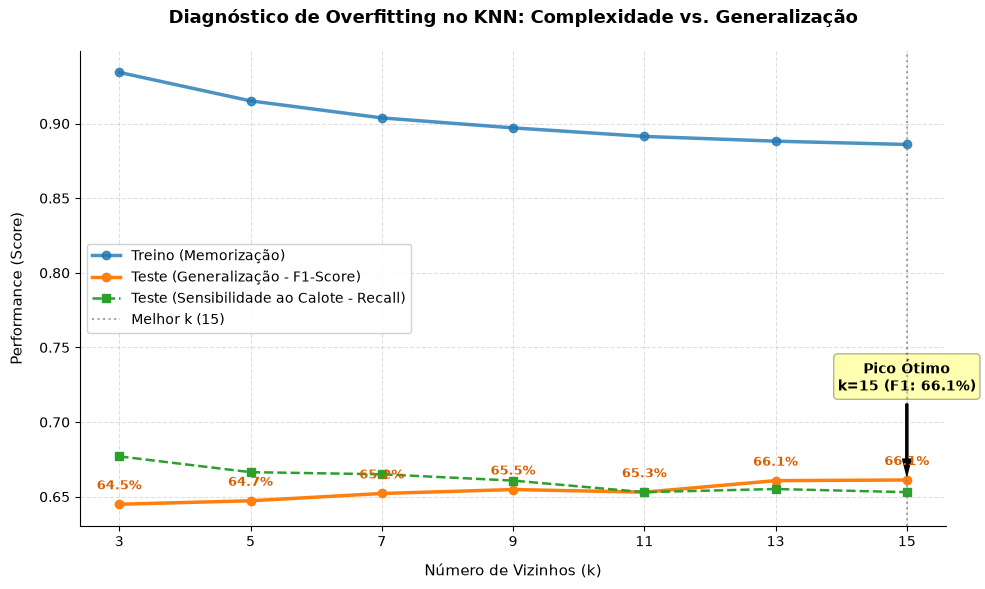

In [29]:
import matplotlib.pyplot as plt

# 1. Identificação automática do melhor K
idx_melhor = df_resultados_knn["f1_teste"].idxmax()
k_melhor = df_resultados_knn.loc[idx_melhor, "k"]
f1_melhor = df_resultados_knn.loc[idx_melhor, "f1_teste"]

plt.figure(figsize=(10, 6))

# 2. Plotagem das linhas principais
plt.plot(
    df_resultados_knn["k"],
    df_resultados_knn["f1_treino"],
    marker="o",
    linewidth=2.5,
    label="Treino (Memorização)",
    color="#1f77b4",
    alpha=0.8,
)
plt.plot(
    df_resultados_knn["k"],
    df_resultados_knn["f1_teste"],
    marker="o",
    linewidth=2.5,
    label="Teste (Generalização - F1-Score)",
    color="#ff7f0e",
)

# 3. Linha de Recall (Sensibilidade ao risco)
if "recall_teste" in df_resultados_knn.columns:
    plt.plot(
        df_resultados_knn["k"],
        df_resultados_knn["recall_teste"],
        marker="s",
        linestyle="--",
        linewidth=1.8,
        label="Teste (Sensibilidade ao Calote - Recall)",
        color="#2ca02c",
    )

# 4. Linha vertical e seta do campeão
plt.axvline(
    x=k_melhor,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label=f"Melhor k ({k_melhor})",
)
plt.annotate(
    f"Pico Ótimo\nk={k_melhor} (F1: {f1_melhor:.1%})",
    xy=(k_melhor, f1_melhor),
    xytext=(k_melhor, f1_melhor + 0.06),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1.5, headwidth=6),
    fontsize=10,
    fontweight="bold",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3),
)

# 5. AJUSTE: Rótulos de dados acima dos pontos (evita cortar no eixo X) e fonte padrão 'bold'
for x, y in zip(df_resultados_knn["k"], df_resultados_knn["f1_teste"]):
    plt.text(
        x,
        y + 0.008,
        f"{y:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#d95f02",
    )

# 6. Informações descritivas
plt.title(
    "Diagnóstico de Overfitting no KNN: Complexidade vs. Generalização",
    fontsize=13,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Número de Vizinhos (k)", fontsize=11, labelpad=10)
plt.ylabel("Performance (Score)", fontsize=11, labelpad=10)

# 7. Acabamento visual minimalista
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xticks(df_resultados_knn["k"])
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=True, facecolor="white", framealpha=0.9, loc="center left")

# 8. Exibição
plt.tight_layout()
plt.show()

## 5.2 Otimização da Árvore de Decisão e Visualização

In [30]:
from sklearn.metrics import f1_score, recall_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt


resultados_tree = []
# Melhoria 1: Adicionamos 6, 8 e 10 para mapear perfeitamente o pico antes da queda
profundidades = [3, 5, 6, 7, 8, 10, None]

for depth in profundidades:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    # Lembre-se: Árvore não precisa de escalonamento! Usamos X_train_bal direto.
    tree.fit(X_train_bal, y_train_bal)

    pred_train = tree.predict(X_train_bal)
    pred_test = tree.predict(X_test)

    # Melhoria 3: Tratamento elegante para a leitura da profundidade ilimitada
    nome_cenario = "Ilimitada (None)" if depth is None else str(depth)

    resultados_tree.append(
        {
            "max_depth": nome_cenario,
            "f1_treino": f1_score(y_train_bal, pred_train),
            "f1_teste": f1_score(y_test, pred_test),
            # Melhoria 2: Adicionamos o Recall de Teste para foco em Risco de Crédito
            "recall_teste": recall_score(y_test, pred_test),
        }
    )

# Exibição da tabela comparativa
df_resultados_tree = pd.DataFrame(resultados_tree)
display(df_resultados_tree)

,max_depth,f1_treino,f1_teste,recall_teste
0,3,0.788693,0.661683,0.717913
1,5,0.816303,0.717291,0.709450
2,6,0.823022,0.736956,0.722144
3,7,0.832066,0.750735,0.720028
4,8,0.858854,0.678009,0.758815
5,10,0.895546,0.726842,0.758110
6,Ilimitada (None),1.000000,0.711169,0.770099


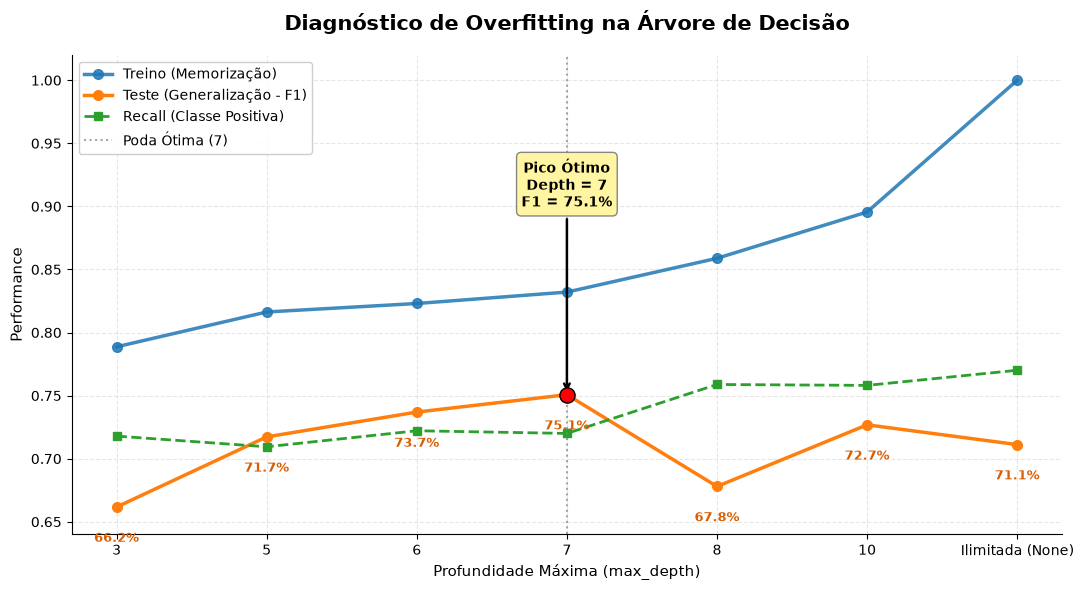

In [31]:
import matplotlib.pyplot as plt

# ==========================================
# Preparação dos dados
# ==========================================
df_tree_plot = df_resultados_tree.copy()

# Transforma os valores em string para o eixo X
df_tree_plot["x_axis"] = [str(v) for v in df_tree_plot["max_depth"]]

# Melhor configuração (maior F1 no teste)
idx_melhor = df_tree_plot["f1_teste"].idxmax()
depth_melhor = df_tree_plot.loc[idx_melhor, "x_axis"]
f1_melhor = df_tree_plot.loc[idx_melhor, "f1_teste"]

# ==========================================
# Figura
# ==========================================
plt.figure(figsize=(11,6))

# ==========================================
# Curva de treino
# ==========================================
plt.plot(
    df_tree_plot["x_axis"],
    df_tree_plot["f1_treino"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#1f77b4",
    alpha=0.85,
    label="Treino (Memorização)"
)

# ==========================================
# Curva de teste
# ==========================================
plt.plot(
    df_tree_plot["x_axis"],
    df_tree_plot["f1_teste"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#ff7f0e",
    label="Teste (Generalização - F1)"
)

# ==========================================
# Recall
# ==========================================
if "recall_teste" in df_tree_plot.columns:

    plt.plot(
        df_tree_plot["x_axis"],
        df_tree_plot["recall_teste"],
        marker="s",
        markersize=6,
        linestyle="--",
        linewidth=2,
        color="#2ca02c",
        label="Recall (Classe Positiva)"
    )

# ==========================================
# Linha da melhor profundidade
# ==========================================
plt.axvline(
    depth_melhor,
    linestyle=":",
    linewidth=1.5,
    color="gray",
    alpha=0.7,
    label=f"Poda Ótima ({depth_melhor})"
)

# ==========================================
# Destaque do melhor ponto
# ==========================================
plt.scatter(
    depth_melhor,
    f1_melhor,
    s=120,
    color="red",
    edgecolor="black",
    zorder=5
)

plt.annotate(
    f"Pico Ótimo\nDepth = {depth_melhor}\nF1 = {f1_melhor:.1%}",
    xy=(depth_melhor, f1_melhor),
    xytext=(depth_melhor, 0.90),
    ha="center",
    fontsize=10,
    fontweight="bold",

    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="#FFF59D",
        ec="gray",
        alpha=0.95
    ),

    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1.8
    )
)

# ==========================================
# Valores do F1
# ==========================================
for x, y in zip(df_tree_plot["x_axis"], df_tree_plot["f1_teste"]):

    plt.text(
        x,
        y-0.020,
        f"{y:.1%}",
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#d95f02"
    )

# ==========================================
# Acabamento
# ==========================================
plt.title(
    "Diagnóstico de Overfitting na Árvore de Decisão",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Profundidade Máxima (max_depth)",
    fontsize=11
)

plt.ylabel(
    "Performance",
    fontsize=11
)

# Ajuste do eixo Y
plt.ylim(0.64, 1.02)

# Grade
plt.grid(
    linestyle="--",
    alpha=0.30
)

# Remove bordas superiores
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Legenda
plt.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=0.95
)

plt.tight_layout()

plt.show()

## Diagnóstico de Overfitting: Síntese do Diagnóstico de Overfitting e Validação de Hiperparâmetros


O monitoramento simultâneo das métricas de Treino e Teste comprovou a atuação do *trade-off* entre viés e variância na modelagem do risco de crédito:

1. **Identificação e Evitação do Overfitting:**
   - **No KNN:** O sobreajuste severo em k=3 (Treino: 93,4% | Teste: 64,5%) foi mitigado ao aumentarmos o hiperparâmetro para k=15 , diluindo o impacto de *outliers* na distância euclidiana.
   - **Na Árvore de Decisão:** A memorização perfeita e prejudicial observada na árvore sem poda (`max_depth=None` com 100% no treino e queda para 71,1% no teste) foi eliminada através do controle de profundidade máxima.

2. **Configurações Campeãs em Generalização:**
   - O hiperparâmetro **`max_depth=7`** na Árvore de Decisão provou ser a configuração ótima de todo o projeto, alcançando **75,07% de F1-Score na base de teste** (superando o KNN campeão em 9 pontos percentuais). A limitação do crescimento evitou a fragmentação dos nós e preservou o poder analítico das variáveis ordinais e proporções financeiras criadas na Feature Engineering.